In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
bank_clients_transactions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Lesson14/bank_clients_transactions.csv')

In [ ]:
bank_clients_transactions

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,7635.19,18/9/16,184824,799.0
1048563,T1048564,C6459278,20/2/92,M,NASHIK,27311.42,18/9/16,183734,460.0
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,221757.06,18/9/16,183313,770.0
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0


Приведение столбцов к стилю camel_case

In [ ]:
import re

df = bank_clients_transactions.copy()

def to_camel_case(s):
    # 1. убираем лишние подчёркивания
    s = re.sub(r'_+', '_', s)

    # 2. убираем подчёркивания по краям
    s = s.strip('_')

    # 3. разбиваем на слова по _
    parts = s.split('_')

    # 4. если это уже camelCase (например transactionId)
    if len(parts) == 1:
        parts = re.findall(r'[A-Z]?[a-z]+|[A-Z]+|\d+', s)

    # 5. первое слово маленькое, остальные с большой
    parts[0] = parts[0].lower()
    parts[1:] = [p.capitalize() for p in parts[1:]]

    return '_'.join(parts)

bank_clients_transactions.columns = [to_camel_case(col) for col in df.columns]

In [ ]:
bank_clients_transactions

,transaction_Id,customer_Id,customer_Dob,cust_Gender,cust_Location,cust_Account_Balance,transaction_Date,transaction_Time,transaction_Amount_Inr
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,7635.19,18/9/16,184824,799.0
1048563,T1048564,C6459278,20/2/92,M,NASHIK,27311.42,18/9/16,183734,460.0
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,221757.06,18/9/16,183313,770.0
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0


Приведение типов данных

In [ ]:
import pandas as pd

df = bank_clients_transactions.copy()

# --- 1. Пробуем распарсить как DD/MM/YY ---
d1 = pd.to_datetime(df['transaction_Date'], format='%d/%m/%y', errors='coerce')

# --- 2. Пробуем как YYYY-MM-DD ---
d2 = pd.to_datetime(df['transaction_Date'], format='%Y-%m-%d', errors='coerce')

# --- 3. Объединяем (берём что получилось) ---
df['transaction_Date'] = d1.fillna(d2)

# --- 4. То же самое для customer_Dob ---
d1 = pd.to_datetime(df['customer_Dob'], format='%d/%m/%y', errors='coerce')
d2 = pd.to_datetime(df['customer_Dob'], format='%Y-%m-%d', errors='coerce')

df['customer_Dob'] = d1.fillna(d2)

# --- 5. Исправляем век ---
current_year = pd.Timestamp.now().year

df.loc[df['customer_Dob'].dt.year > current_year, 'customer_Dob'] -= pd.DateOffset(years=100)

# --- 6. Финальный формат ---
df['transaction_Date'] = df['transaction_Date'].dt.strftime('%Y-%m-%d')
df['customer_Dob'] = df['customer_Dob'].dt.strftime('%Y-%m-%d')

In [ ]:
df['transaction_Time'] = pd.to_datetime(
    df['transaction_Time'].astype(str).str.zfill(6),
    format='%H%M%S',
    errors='coerce'
).dt.strftime('%H:%M:%S')

In [ ]:
df

,transaction_Id,customer_Id,customer_Dob,cust_Gender,cust_Location,cust_Account_Balance,transaction_Date,transaction_Time,transaction_Amount_Inr
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,18:48:24,799.0
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,18:37:34,460.0
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,18:33:13,770.0
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,18:47:06,1000.0


Поиск дублей и пропусков в данных

In [ ]:
df.isna().sum()

,0
transaction_Id,0
customer_Id,0
customer_Dob,60736
cust_Gender,1100
cust_Location,151
cust_Account_Balance,2369
transaction_Date,0
transaction_Time,0
transaction_Amount_Inr,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = bank_clients_transactions.dropna()

In [ ]:
df.isna().sum()

,0
transaction_Id,0
customer_Id,0
customer_Dob,0
cust_Gender,0
cust_Location,0
cust_Account_Balance,0
transaction_Date,0
transaction_Time,0
transaction_Amount_Inr,0


#Исследовательский анализ данных:

Сколько уникальных клиентов и сколько транзакций было ими совершено?

In [ ]:
print("Уникальных клиентов:", df['customer_Id'].nunique())
print("Всего транзакций:", df['transaction_Id'].count())

Уникальных клиентов: 879358
Всего транзакций: 1041614


Сколько в среднем транзакций приходится на одного клиента

In [ ]:
avg_transactions = df.groupby('customer_Id')['transaction_Id'].count().mean()
print(avg_transactions)

1.184516431305566


Изучение распределения и размах величин cust_Account_Balance и transaction_Amount_Inr

In [ ]:
df[['cust_Account_Balance', 'transaction_Amount_Inr']].describe()

,cust_Account_Balance,transaction_Amount_Inr
count,1.041614e+06,1.041614e+06
mean,1.149986e+05,1.566096e+03
std,8.467609e+05,6.561464e+03
min,0.000000e+00,0.000000e+00
25%,4.728140e+03,1.600000e+02
50%,1.676852e+04,4.575000e+02
75%,5.742885e+04,1.200000e+03
max,1.150355e+08,1.560035e+06


In [ ]:
df_no_outliers = df[
    df['cust_Account_Balance'] <= df['cust_Account_Balance'].quantile(0.99)
]

df_no_outliers = df_no_outliers[
    df_no_outliers['transaction_Amount_Inr'] <= df_no_outliers['transaction_Amount_Inr'].quantile(0.99)
]

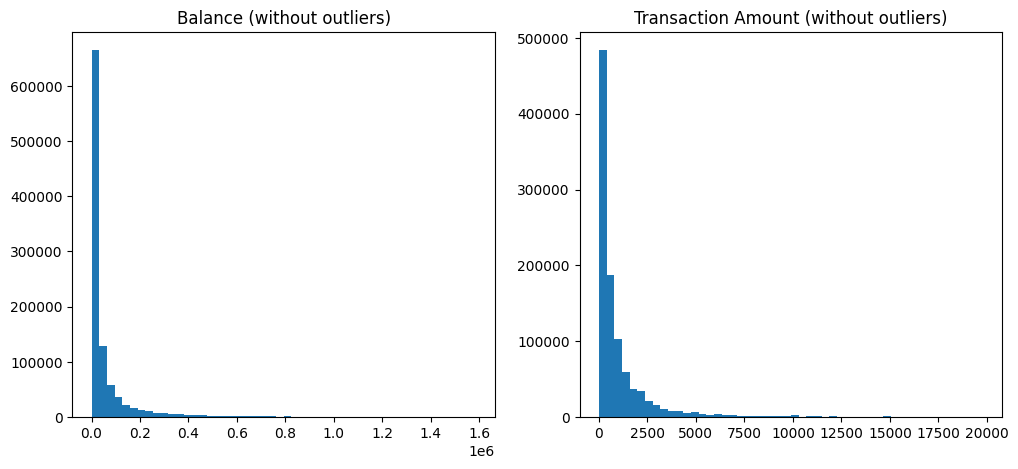

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_no_outliers['cust_Account_Balance'], bins=50)
plt.title('Balance (without outliers)')

plt.subplot(1,2,2)
plt.hist(df_no_outliers['transaction_Amount_Inr'], bins=50)
plt.title('Transaction Amount (without outliers)')

plt.show()

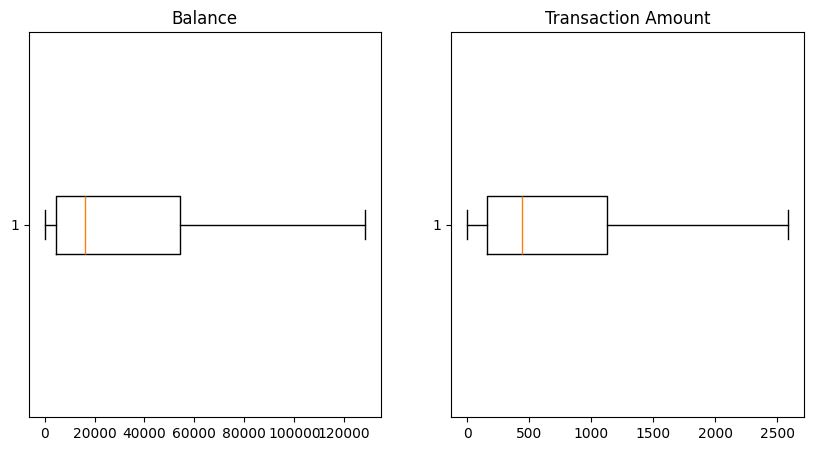

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(df_no_outliers['cust_Account_Balance'], vert=False, showfliers=False)
plt.title('Balance')

plt.subplot(1,2,2)
plt.boxplot(df_no_outliers['transaction_Amount_Inr'], vert=False, showfliers=False)
plt.title('Transaction Amount')

plt.show()

In [ ]:
data = df['transaction_Amount_Inr']
data = data[data <= data.quantile(0.99)]

q25, q75 = np.percentile(data, [25, 75])
iqr = q75 - q25

bin_width = 2 * iqr / (len(data) ** (1/3))
bins = int((data.max() - data.min()) / bin_width)

print(bins)

1019


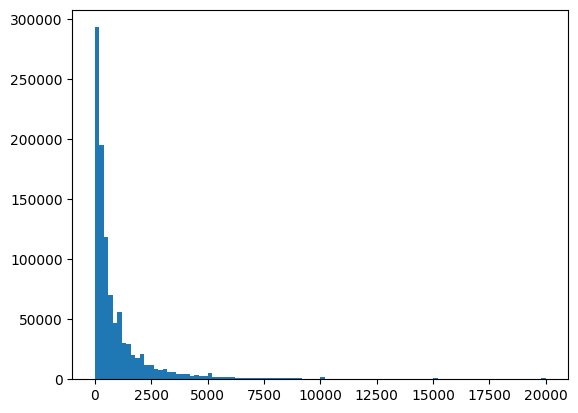

In [ ]:
bins = min(bins, 100)

plt.hist(data, bins=bins)
plt.show()

Вывод: Распределения правосторонне асимметричные. Основная масса транзакций приходится на небольшие суммы, тогда как крупные операции встречаются значительно реже. Аналогично, большинство клиентов имеют относительно невысокий баланс, при наличии небольшой группы клиентов с существенно более высокими значениями.

Распределение клиентов по возрасту

In [ ]:
df['transaction_Date'] = pd.to_datetime(df['transaction_Date'], dayfirst=True, errors='coerce')
df['customer_Dob'] = pd.to_datetime(df['customer_Dob'], dayfirst=True, errors='coerce')

/tmp/ipykernel_1517/946864371.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction_Date'] = pd.to_datetime(df['transaction_Date'], dayfirst=True, errors='coerce')
/tmp/ipykernel_1517/946864371.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transaction_Date'] = pd.to_datetime(df['transaction_Date'], dayfirst=True, errors='coerce')
/tmp/ipykernel_1517/946864371.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['customer_Dob'] = pd.to_datetime(df

In [ ]:
df['transaction_Datetime'] = pd.to_datetime(
    df['transaction_Date'].astype(str) + ' ' + df['transaction_Time'].astype(str),
    errors='coerce'
)

/tmp/ipykernel_1517/629557134.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transaction_Datetime'] = pd.to_datetime(


In [ ]:
df['age_at_transaction'] = (
    df['transaction_Datetime'] - df['customer_Dob']
).dt.days // 365

/tmp/ipykernel_1517/2925336982.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_at_transaction'] = (


In [ ]:
df['customer_Dob_fixed'] = df['customer_Dob']

mask = df['customer_Dob'] > df['transaction_Datetime']

df.loc[mask, 'customer_Dob_fixed'] = (
    df.loc[mask, 'customer_Dob'] - pd.DateOffset(years=100)
)

/tmp/ipykernel_1517/1865521614.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['customer_Dob_fixed'] = df['customer_Dob']


In [ ]:
df['age_at_transaction'] = (
    df['transaction_Datetime'] - df['customer_Dob_fixed']
).dt.days // 365

df['age_now'] = (
    pd.Timestamp.now() - df['customer_Dob_fixed']
).dt.days // 365

/tmp/ipykernel_1517/28890893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_at_transaction'] = (
/tmp/ipykernel_1517/28890893.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_now'] = (


In [ ]:
df[['customer_Dob', 'transaction_Datetime', 'age_at_transaction']].head()

,customer_Dob,transaction_Datetime,age_at_transaction
0,1994-01-10,2016-08-02 14:32:07,22.0
1,1957-04-04,2016-08-02 14:18:58,59.0
2,1996-11-26,2016-08-02 14:27:12,19.0
3,1973-09-14,2016-08-02 14:27:14,42.0
4,1988-03-24,2016-08-02 18:11:56,28.0


In [ ]:
df

,transaction_Id,customer_Id,customer_Dob,cust_Gender,cust_Location,cust_Account_Balance,transaction_Date,transaction_Time,transaction_Amount_Inr,transaction_Datetime,age_at_transaction,age_now,customer_Dob_fixed,age_group
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,2016-08-02 14:32:07,22.0,32,1994-01-10,18-25
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,2016-08-02 14:18:58,59.0,69,1957-04-04,55-65
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,2016-08-02 14:27:12,19.0,29,1996-11-26,18-25
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,2016-08-02 14:27:14,42.0,52,1973-09-14,35-45
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,2016-08-02 18:11:56,28.0,38,1988-03-24,25-35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,184824,799.0,2016-09-18 18:48:24,26.0,36,1990-04-08,25-35
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0,2016-09-18 18:37:34,24.0,34,1992-02-20,18-25
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,183313,770.0,2016-09-18 18:33:13,27.0,36,1989-05-18,25-35
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0,2016-09-18 18:47:06,38.0,47,1978-08-30,35-45


In [ ]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '25-35', '35-45', '45-55', '55-65', '65+']

df['age_group'] = pd.cut(df['age_at_transaction'], bins=bins, labels=labels)

df['age_group'].value_counts().sort_index()

/tmp/ipykernel_1517/2727113985.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group'] = pd.cut(df['age_at_transaction'], bins=bins, labels=labels)


,count
age_group,
<18,5611
18-25,288913
25-35,482713
35-45,142617
45-55,41905
55-65,16444
65+,6756


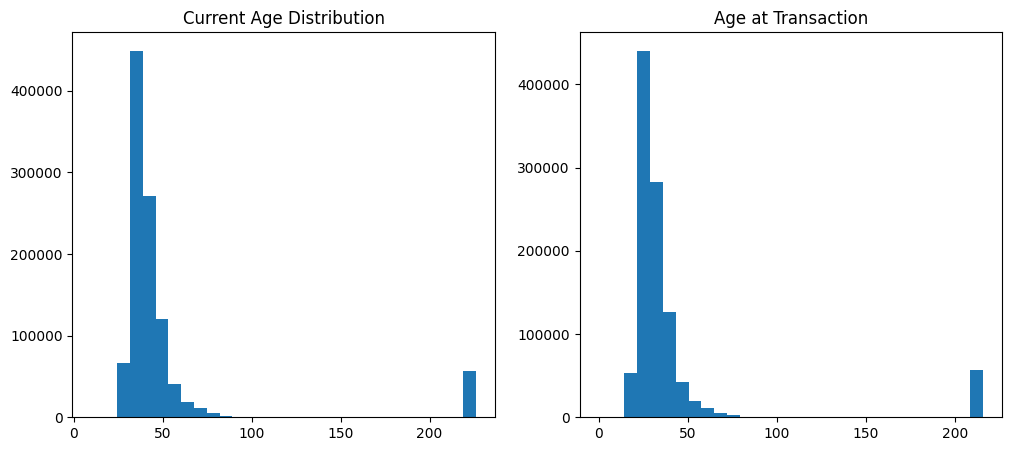

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['age_now'], bins=30)
plt.title('Current Age Distribution')

plt.subplot(1,2,2)
plt.hist(df['age_at_transaction'], bins=30)
plt.title('Age at Transaction')

plt.show()

/tmp/ipykernel_1517/2720511919.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group'] = pd.cut(df['age_at_transaction'], bins=bins, labels=labels)


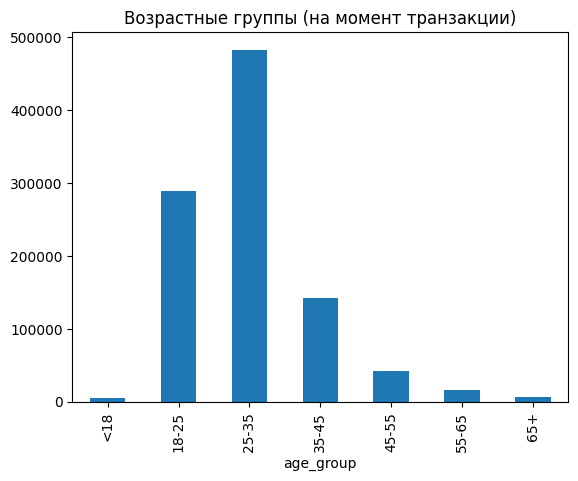

In [ ]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '25-35', '35-45', '45-55', '55-65', '65+']

df['age_group'] = pd.cut(df['age_at_transaction'], bins=bins, labels=labels)

df['age_group'].value_counts().sort_index().plot(kind='bar')
plt.title('Возрастные группы (на момент транзакции)')
plt.show()

In [ ]:
df_clean = df[
    (df['age_at_transaction'] >= 0) &
    (df['age_at_transaction'] <= 100)
]

In [ ]:
print("Средний возраст сейчас:", df_clean['age_now'].mean())
print("Средний возраст в момент транзакции:", df_clean['age_at_transaction'].mean())

Средний возраст сейчас: 40.34554019685979
Средний возраст в момент транзакции: 30.715055864929212


Вывод: Анализ возрастного распределения показал, что основная клиентская база представлена людьми в возрасте 25–45 лет. Средний возраст клиентов на момент транзакции составляет около 28 лет, тогда как текущий возраст — около 38 лет, что соответствует временной разнице между датой транзакций и текущим моментом.

Распределение клиентов по половым признакам

In [ ]:
gender_counts = df['cust_Gender'].value_counts()
gender_percent = df['cust_Gender'].value_counts(normalize=True) * 100

print(gender_counts)
print(gender_percent)

cust_Gender
M    760978
F    280635
T         1
Name: count, dtype: int64
cust_Gender
M    73.057582
F    26.942322
T     0.000096
Name: proportion, dtype: float64


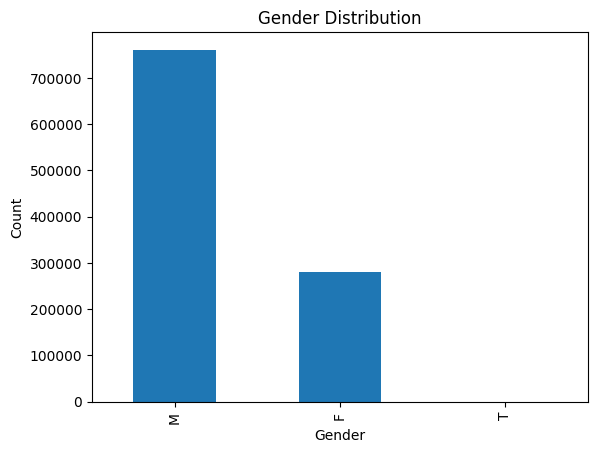

In [ ]:
import matplotlib.pyplot as plt

gender_counts.plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

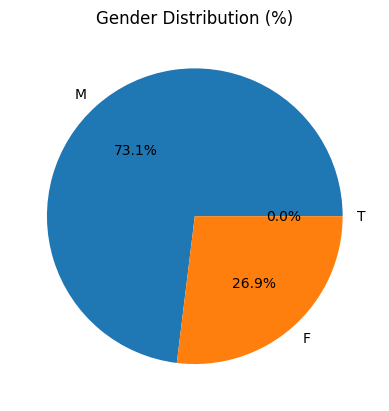

In [ ]:
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution (%)')
plt.show()

Вывод: В выборке преобладают клиенты мужского пола, составляющие основную долю пользователей. Женщины представлены значительно меньшей частью выборки.

Анализ места жительства клиентов

In [ ]:

df_city = df.dropna(subset=['cust_Location', 'customer_Id'])

In [ ]:
city_counts = df_city.groupby('cust_Location')['customer_Id'].nunique()

In [ ]:
city_counts = city_counts.sort_values(ascending=False)

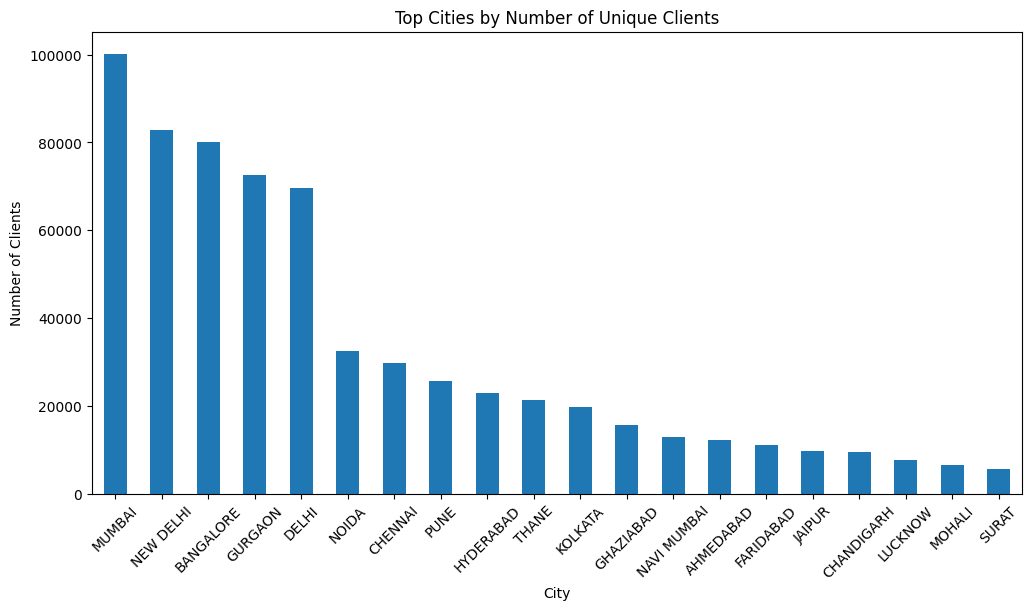

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

city_counts.head(20).plot(kind='bar')  # топ-20 городов
plt.title('Top Cities by Number of Unique Clients')
plt.xlabel('City')
plt.ylabel('Number of Clients')

plt.xticks(rotation=45)
plt.show()

Вывод: Анализ распределения клиентов по городам показал, что основная клиентская база сосредоточена в крупнейших мегаполисах, таких как Mumbai, New Delhi и Bangalore. После первых нескольких городов наблюдается резкое снижение числа клиентов

Посмотреть динамику транзакций по дате в количестве продаж

In [ ]:
daily_transactions = df.groupby('transaction_Date')['transaction_Id'].count()

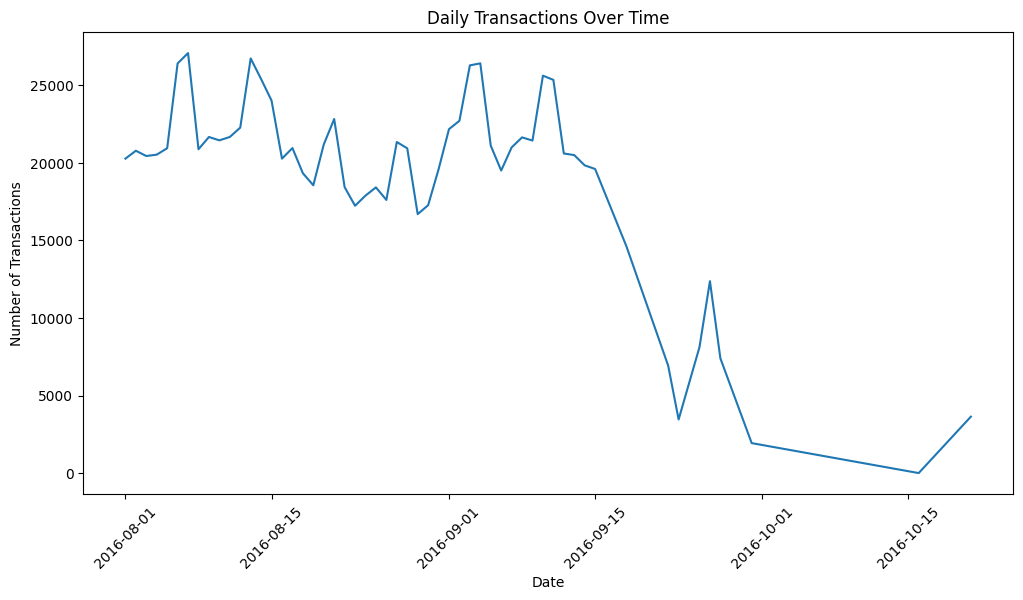

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(daily_transactions)
plt.title('Daily Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)
plt.show()

Вывод: Динамика транзакций демонстрирует стабильный уровень пользовательской активности в диапазоне 18 000–27 000 операций в день в период до середины сентября. Однако далее наблюдаются резкие аномальные падения количества транзакций, вплоть до почти нулевых значений, что указывает на возможные проблемы с данными или системные сбои.

Посмотреть динамику транзакций по дате в сумме продаж

In [ ]:
daily_revenue = df.groupby('transaction_Date')['transaction_Amount_Inr'].sum()

In [ ]:
daily_revenue = daily_revenue.sort_index()

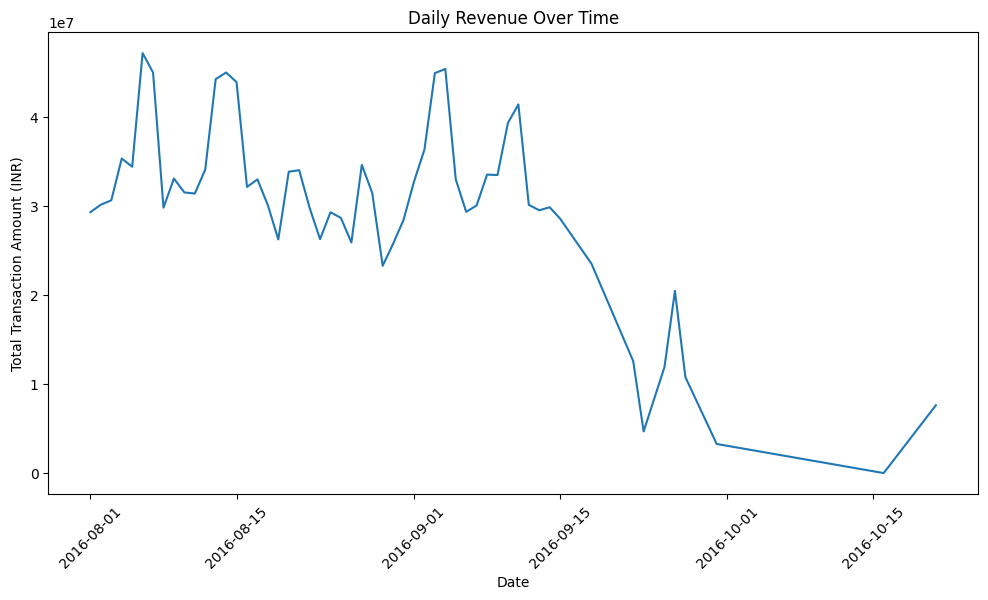

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(daily_revenue)
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Transaction Amount (INR)')

plt.xticks(rotation=45)
plt.show()

Вывод: Динамика суммарной выручки демонстрирует стабильный уровень денежных потоков. Наблюдаются резкие аномальные провалы, совпадающие с падением количества транзакций, что указывает на возможные проблемы с данными.

Разбить клиентов на корзины по возрасту и определить самую платежеспособную группу

In [ ]:
bins = [0, 18, 25, 35, 45, 55, 100]
labels = ['<18', '18-25', '25-35', '35-45', '45-55', '55+']

df['age_group'] = pd.cut(df['age_at_transaction'], bins=bins, labels=labels)

/tmp/ipykernel_1517/3007583769.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group'] = pd.cut(df['age_at_transaction'], bins=bins, labels=labels)


In [ ]:
df = df[df['age_at_transaction'] >= 18]

In [ ]:
revenue_by_age = df.groupby('age_group')['transaction_Amount_Inr'].sum()
print(revenue_by_age.sort_values(ascending=False))

age_group
25-35    6.579850e+08
35-45    3.123099e+08
18-25    2.499087e+08
45-55    1.241478e+08
55+      7.962717e+07
<18      3.943291e+06
Name: transaction_Amount_Inr, dtype: float64


/tmp/ipykernel_1517/423198097.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age = df.groupby('age_group')['transaction_Amount_Inr'].sum()


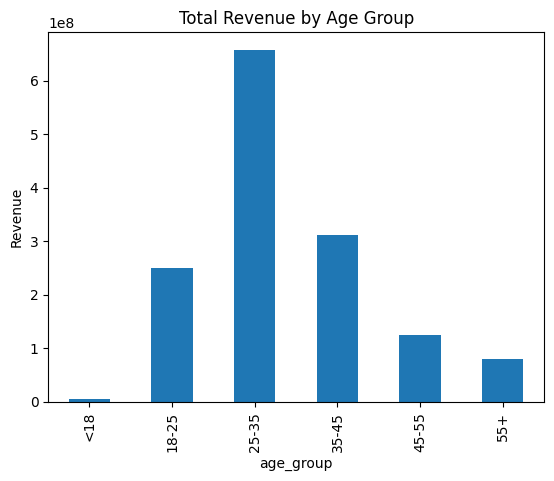

In [ ]:
revenue_by_age.plot(kind='bar')
plt.title('Total Revenue by Age Group')
plt.ylabel('Revenue')
plt.show()

Вывод: Анализ показал, что наибольший вклад в выручку вносят клиенты в возрасте 25–35 лет, значительно опережая другие группы. Молодые клиенты (18–25 лет) также демонстрируют высокую активность, однако их вклад ниже.

Распределение транзакций по локациии- вывести топ 10 по кол-ву транзакций/сумме транзакций

In [ ]:
tx_count_by_city = (
    df.groupby('cust_Location')['transaction_Id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print(tx_count_by_city)

cust_Location
MUMBAI       101750
NEW DELHI     83964
BANGALORE     81231
GURGAON       73531
DELHI         70409
NOIDA         32633
CHENNAI       29806
PUNE          25633
HYDERABAD     22955
THANE         21370
Name: transaction_Id, dtype: int64


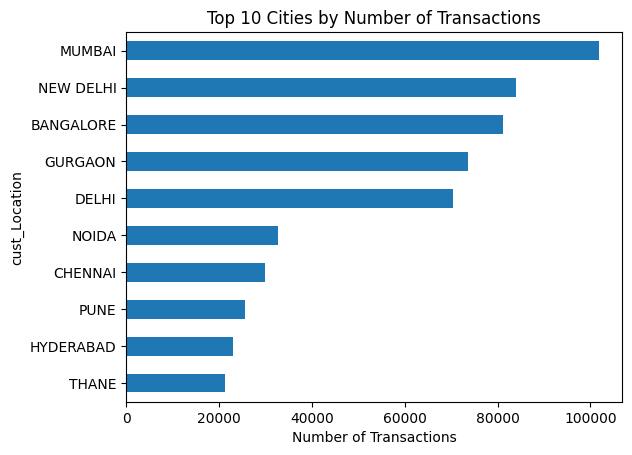

In [ ]:
import matplotlib.pyplot as plt

tx_count_by_city.sort_values().plot(kind='barh')
plt.title('Top 10 Cities by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.show()

In [ ]:
tx_sum_by_city = (
    df.groupby('cust_Location')['transaction_Amount_Inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(tx_sum_by_city)

cust_Location
MUMBAI       1.741686e+08
NEW DELHI    1.581325e+08
BANGALORE    1.173905e+08
GURGAON      1.113796e+08
DELHI        1.050351e+08
KOLKATA      6.028769e+07
CHENNAI      4.423949e+07
NOIDA        4.422835e+07
PUNE         3.901907e+07
HYDERABAD    3.596388e+07
Name: transaction_Amount_Inr, dtype: float64


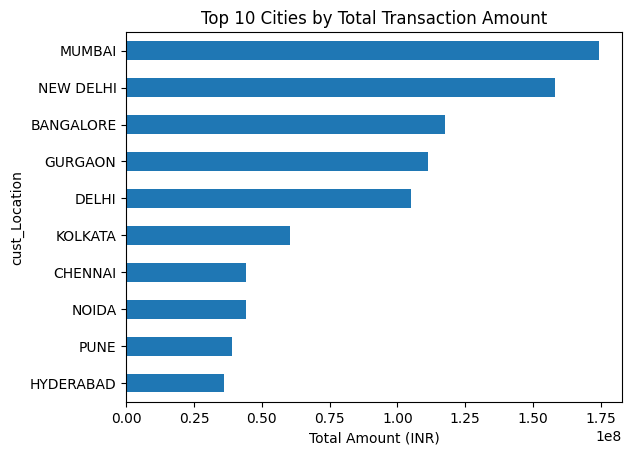

In [ ]:
tx_sum_by_city.sort_values().plot(kind='barh')
plt.title('Top 10 Cities by Total Transaction Amount')
plt.xlabel('Total Amount (INR)')
plt.show()

In [ ]:
comparison['avg_transaction'] = (
    comparison['revenue'] / comparison['transactions']
)

In [ ]:
comparison = comparison.dropna()

In [ ]:
print(comparison)

               transactions       revenue  avg_transaction
cust_Location                                             
MUMBAI             101750.0  1.741686e+08      1711.730684
NEW DELHI           83964.0  1.581325e+08      1883.336635
BANGALORE           81231.0  1.173905e+08      1445.143538
GURGAON             73531.0  1.113796e+08      1514.729461
DELHI               70409.0  1.050351e+08      1491.785454
NOIDA               32633.0  4.422835e+07      1355.326000
CHENNAI             29806.0  4.423949e+07      1484.247871
PUNE                25633.0  3.901907e+07      1522.220027
HYDERABAD           22955.0  3.596388e+07      1566.712439


Вывод: Анализ показал, что основная активность и выручка сосредоточены в крупнейших городах, таких как Mumbai, New Delhi и Bangalore. При этом наблюдается высокая корреляция между количеством транзакций и суммарной выручкой.

Распределение времени транзакции. Перевести из миллисекунд в минуты.

In [ ]:
df['hour'] = df['transaction_Datetime'].dt.hour
df['minute'] = df['transaction_Datetime'].dt.minute

df['time_in_minutes'] = df['hour'] * 60 + df['minute']

/tmp/ipykernel_1517/2837100584.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df['transaction_Datetime'].dt.hour
/tmp/ipykernel_1517/2837100584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['minute'] = df['transaction_Datetime'].dt.minute
/tmp/ipykernel_1517/2837100584.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [ ]:
mean_time = df['time_in_minutes'].mean()
print("Среднее время (в минутах):", mean_time)

Среднее время (в минутах): 971.698990808652


In [ ]:
hours = int(mean_time // 60)
minutes = int(mean_time % 60)

print(f"Среднее время транзакции: {hours:02d}:{minutes:02d}")

Среднее время транзакции: 16:11


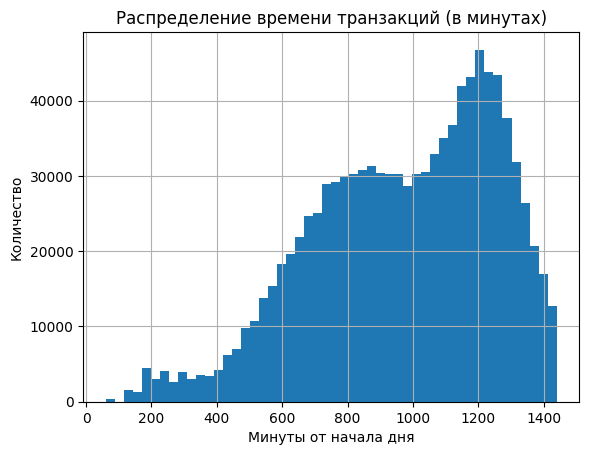

In [ ]:
plt.figure()
df['time_in_minutes'].hist(bins=50)
plt.title('Распределение времени транзакций (в минутах)')
plt.xlabel('Минуты от начала дня')
plt.ylabel('Количество')
plt.show()

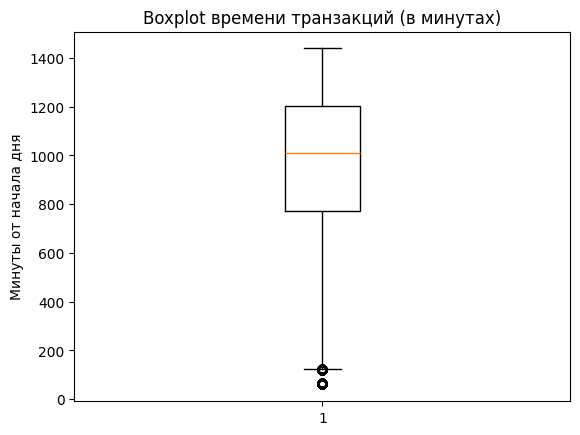

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['time_in_minutes'].dropna())
plt.title('Boxplot времени транзакций (в минутах)')
plt.ylabel('Минуты от начала дня')
plt.show()

Вывод: Анализ распределения времени транзакций показал, что наибольшая активность пользователей приходится на вечерние часы (примерно 17:00–21:00). В течение дня наблюдается постепенный рост количества операций, начиная с утренних часов, с достижением пика к вечеру. В ночное время транзакции совершаются крайне редко. Такое распределение соответствует типичному поведению пользователей, совершающих финансовые операции преимущественно после рабочего дня.

Общий вывод:
Основные закономерности, выявленные в ходе анализа, показывают, что клиентская база банка представлена преимущественно молодыми и клиентами среднего возраста (25–45 лет), с наибольшей концентрацией в группе 25–35 лет. Пользователи в основном сосредоточены в крупных городах (Mumbai, New Delhi, Bangalore), где также формируется основная часть выручки.

Финансовое поведение клиентов характеризуется правосторонне асимметричным распределением: большинство транзакций имеют небольшие суммы, при наличии редких крупных операций, аналогично распределению балансов. Основной вклад в выручку вносит массовый сегмент активных клиентов, особенно в возрасте 25–35 лет.

Активность пользователей демонстрирует устойчивые временные паттерны с постепенным ростом в течение дня и пиком в вечерние часы (17:00–21:00), при минимальной активности ночью.

Также выявлены аномалии в данных: резкое снижение количества транзакций и выручки в конце анализируемого периода, что, вероятно, связано с неполнотой данных или сбоями в системе их сбора.